In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('data.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nTarget distribution:")
print(df['Class'].value_counts())

Dataset shape: (171, 1204)

First few rows:
   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH 


Class distribution:
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64

Imbalance ratio: 2.05:1


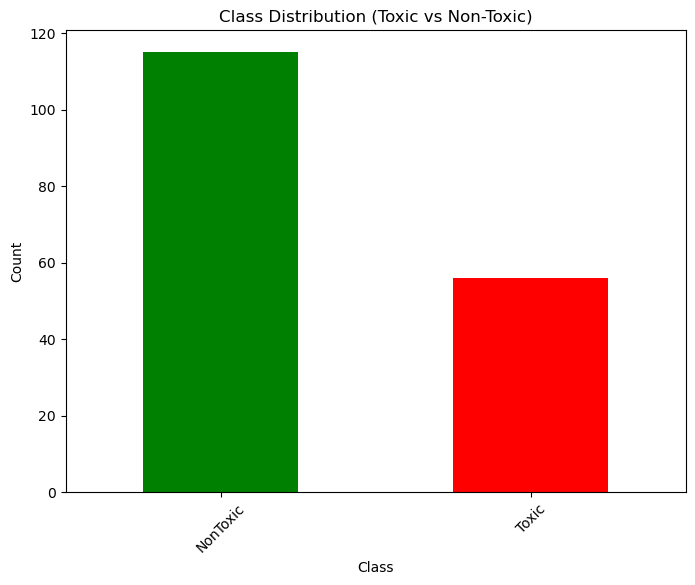

In [3]:
# Check for class imbalance
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nImbalance ratio: {df['Class'].value_counts().iloc[0]/df['Class'].value_counts().iloc[1]:.2f}:1")

# Visualize class distribution
plt.figure(figsize=(8, 6))
df['Class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution (Toxic vs Non-Toxic)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")
if missing_values.sum() > 0:
    print("\nColumns with missing values:")
    print(missing_values[missing_values > 0])
else:
    print("No missing values found!")

# Check for infinite values
inf_values = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"\nTotal infinite values: {inf_values}")

Total missing values: 0
No missing values found!

Total infinite values: 0


In [7]:
# Basic statistics of numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"Number of numeric columns: {len(numeric_cols)}")

# Check variance of features
variances = df[numeric_cols].var()
low_variance_cols = variances[variances < 1e-10].index.tolist()
print(f"\nColumns with near-zero variance: {len(low_variance_cols)}")
if len(low_variance_cols) > 0:
    print(f"Examples: {low_variance_cols[:5]}")

# Check for constant columns
constant_cols = [col for col in numeric_cols if df[col].nunique() == 1]
print(f"\nConstant columns: {len(constant_cols)}")
if len(constant_cols) > 0:
    print(f"Examples: {constant_cols[:5]}")

Number of numeric columns: 1203

Columns with near-zero variance: 0

Constant columns: 0


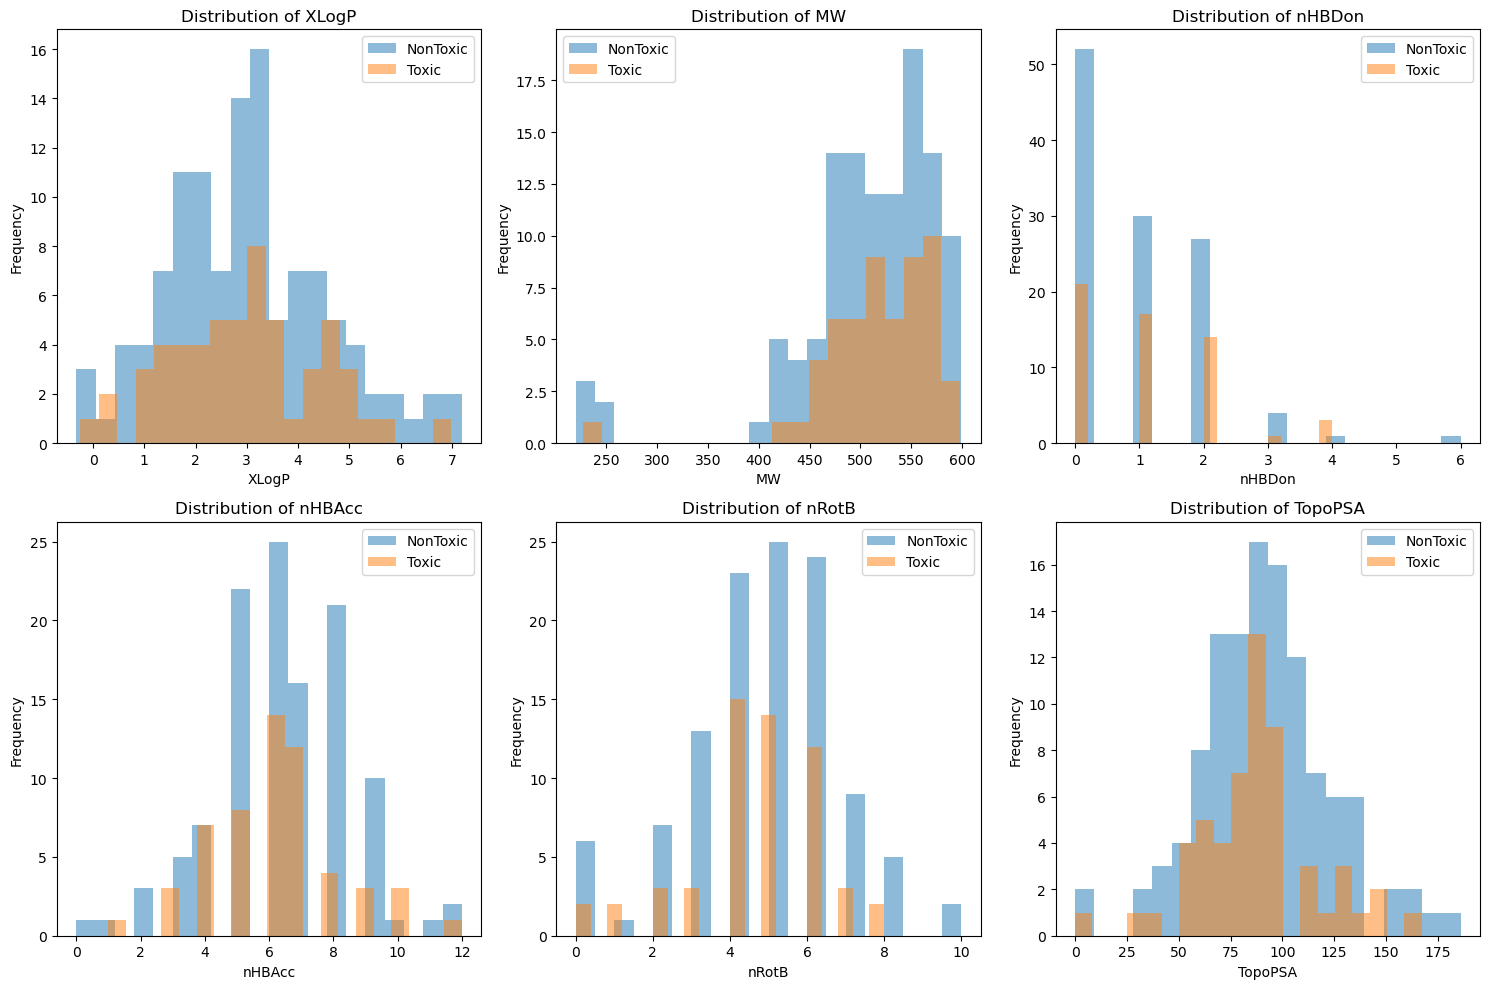

In [9]:
# Visualize distribution of some important features
important_features = ['XLogP', 'MW', 'nHBDon', 'nHBAcc', 'nRotB', 'TopoPSA']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(important_features):
    if feature in df.columns:
        for class_label in df['Class'].unique():
            subset = df[df['Class'] == class_label]
            axes[i].hist(subset[feature], alpha=0.5, label=class_label, bins=20)
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
        axes[i].legend()
    else:
        axes[i].text(0.5, 0.5, f'{feature} not found', ha='center', va='center')
        axes[i].set_title(f'{feature} (Missing)')

plt.tight_layout()
plt.show()

In [11]:
# Correlation analysis
# Since we have many features, let's check correlation with target
# First encode target
le = LabelEncoder()
y_encoded = le.fit_transform(df['Class'])

# Calculate correlation with target
correlations = []
for col in numeric_cols:
    corr = abs(df[col].corr(pd.Series(y_encoded)))
    correlations.append((col, corr))

# Sort by absolute correlation
correlations.sort(key=lambda x: x[1], reverse=True)

print("Top 20 features correlated with target:")
for feature, corr in correlations[:20]:
    print(f"{feature}: {corr:.4f}")

Top 20 features correlated with target:
EE_Dt: 0.2148
C2SP2: 0.1894
AATSC7p: 0.1655
SpDiam_Dt: 0.1650
MLogP: 0.1644
MATS7p: 0.1636
nAcid: 0.1602
nwHBa: 0.1574
GATS7v: 0.1565
SpMin4_Bhi: 0.1557
ATSC1v: 0.1557
AATS8m: 0.1541
ETA_Beta_ns: 0.1526
AATS8v: 0.1524
SpMin4_Bhs: 0.1523
SpMin3_Bhi: 0.1515
nHBint6: 0.1512
SpMAD_Dt: 0.1508
MDEC-23: 0.1501
SP-5: 0.1498


In [13]:
# Data Preprocessing

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes: {le.classes_}")

# Handle any infinite values
X = X.replace([np.inf, -np.inf], np.nan)
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts())

Classes: ['NonToxic' 'Toxic']

Training set size: (136, 1203)
Test set size: (35, 1203)

Training set class distribution:
0    91
1    45
Name: count, dtype: int64

Test set class distribution:
0    24
1    11
Name: count, dtype: int64


In [15]:
# Feature Selection using Random Forest

# Initialize Random Forest for feature selection
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)

# Fit the model
rf_selector.fit(X_train, y_train)

# Get feature importances
importances = rf_selector.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 20 most important features:")
print(feature_importance_df.head(20))

# Select features using SelectFromModel
selector = SelectFromModel(rf_selector, threshold='median', prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

print(f"\nOriginal number of features: {X_train.shape[1]}")
print(f"Number of features after selection: {X_train_selected.shape[1]}")

# Get selected feature names
selected_features = X.columns[selector.get_support()].tolist()
print(f"\nSelected features (first 20): {selected_features[:20]}")

Top 20 most important features:
          feature  importance
230     SpDiam_Dt    0.007690
545        MATS5m    0.007562
15     SpMax8_Bhi    0.007184
1102      VR2_Dzv    0.006899
782        GATS7c    0.006625
645         EE_Dt    0.005725
1096     SpMAD_Dt    0.005339
98        MDEC-23    0.005189
183       VR2_Dzp    0.005029
199   ETA_Eta_F_L    0.004803
655       SpMAD_D    0.004738
587       AATSC8i    0.004726
433          SC-5    0.004656
817        ATSC6m    0.004645
899        ATSC5i    0.004584
349        ATSC3v    0.004524
395        ATSC5s    0.004403
362    SpMax7_Bhm    0.004337
364    SpMax7_Bhp    0.004168
547        MATS5i    0.004164

Original number of features: 1203
Number of features after selection: 602

Selected features (first 20): ['MATS3v', 'MATS3s', 'minHBint8', 'MATS3e', 'MATS3c', 'minHBint2', 'MATS3m', 'minHBint4', 'MATS3i', 'VR3_Dt', 'SpMax8_Bhi', 'ECCEN', 'SpMax8_Bhv', 'BIC5', 'ATS7p', 'ATS7m', 'khs.sssCH', 'minHBint5', 'minssCH2', 'SpMax_DzZ']


In [18]:
# Build Ensemble Model with Cross-Validation

# Create individual models
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

# Create voting classifier
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='soft'  # Use probability voting
)

# Create pipeline with scaling
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', ensemble_model)
])

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(pipeline, X_train_selected, y_train, cv=cv, scoring='accuracy')
cv_roc_auc = cross_val_score(pipeline, X_train_selected, y_train, cv=cv, scoring='roc_auc')

print("Cross-Validation Results:")
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"CV ROC-AUC: {cv_roc_auc.mean():.4f} (+/- {cv_roc_auc.std() * 2:.4f})")

Cross-Validation Results:
CV Accuracy: 0.6394 (+/- 0.1856)
CV ROC-AUC: 0.5810 (+/- 0.1027)



FINAL MODEL PERFORMANCE ON TEST SET
Test Accuracy: 0.6857
Test ROC-AUC: 0.6894

Classification Report:
              precision    recall  f1-score   support

    NonToxic       0.74      0.83      0.78        24
       Toxic       0.50      0.36      0.42        11

    accuracy                           0.69        35
   macro avg       0.62      0.60      0.60        35
weighted avg       0.67      0.69      0.67        35



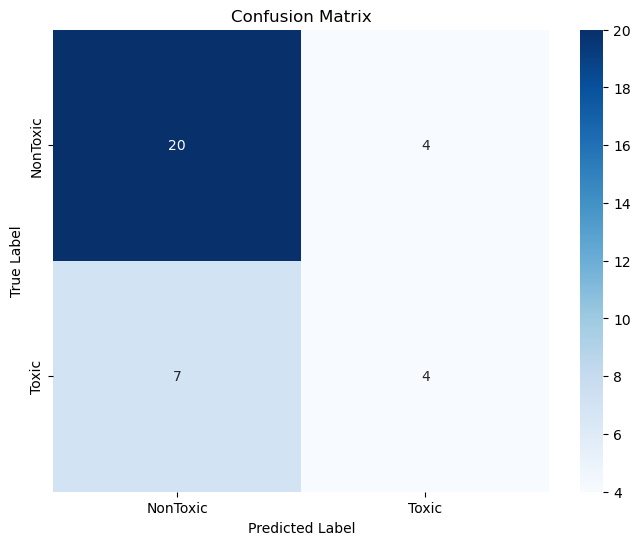

In [20]:
# Train final model and evaluate on test set
pipeline.fit(X_train_selected, y_train)
y_pred = pipeline.predict(X_test_selected)
y_pred_proba = pipeline.predict_proba(X_test_selected)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print("\n" + "="*50)
print("FINAL MODEL PERFORMANCE ON TEST SET")
print("="*50)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

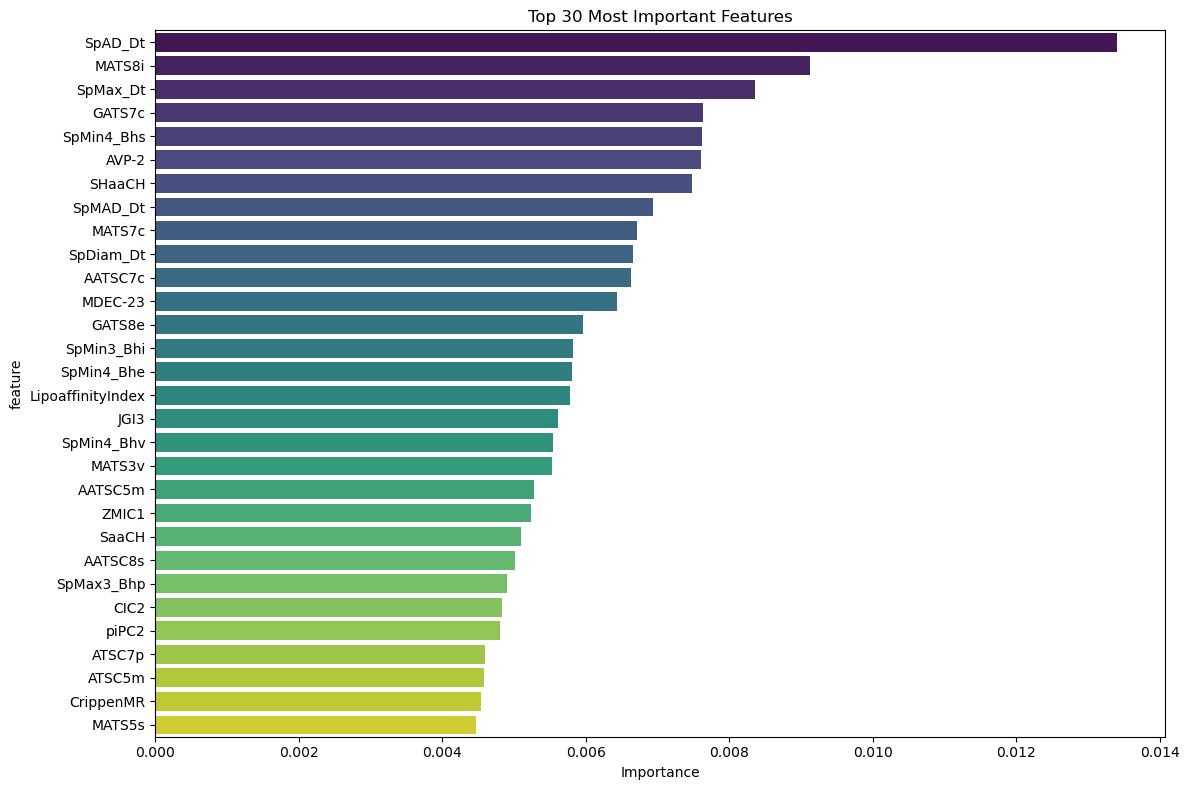


Top 10 Most Important Features:
        feature  importance
72      SpAD_Dt    0.013411
460      MATS8i    0.009133
435    SpMax_Dt    0.008365
396      GATS7c    0.007633
422  SpMin4_Bhs    0.007625
389       AVP-2    0.007607
205      SHaaCH    0.007480
550    SpMAD_Dt    0.006931
173      MATS7c    0.006720
121   SpDiam_Dt    0.006655


In [22]:
# Feature Importance Analysis from the trained Random Forest
rf_model_final = pipeline.named_steps['classifier'].named_estimators_['rf']
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_model_final.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 30 features
plt.figure(figsize=(12, 8))
top_30_features = feature_importance.head(30)
sns.barplot(data=top_30_features, x='importance', y='feature', palette='viridis')
plt.title('Top 30 Most Important Features')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

In [24]:
# Save the model and preprocessors
import joblib

# Save the pipeline
joblib.dump(pipeline, 'toxic_prediction_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(selector, 'feature_selector.pkl')

print("\nModel and preprocessors saved successfully!")


Model and preprocessors saved successfully!
